# Financial Data Analysis Notebook
This notebook performs comprehensive financial data analysis including data retrieval, exploratory analysis, metric calculations, visualizations, and statistical testing.

## 1. Import Required Libraries
Import necessary libraries including pandas, NumPy, matplotlib, seaborn, and yfinance for financial data retrieval.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Financial Data
Load financial data from sources such as CSV files or APIs using yfinance to retrieve stock prices and financial indicators.

In [7]:
# Define date range for analysis
end_date = datetime.now()
start_date = end_date - timedelta(days=365)

# Download stock data using yfinance
tickers = ['AAPL', 'MSFT', 'GOOGL']
data = yf.download(tickers, start=start_date, end=end_date, progress=False)
print(data.columns)
# Use closing prices for analysis
close_prices = data['Close']

print(f"Data shape: {close_prices.shape}")
print(f"\nData period: {start_date.date()} to {end_date.date()}")
print(f"\nFirst few rows:\n{close_prices.head()}")

MultiIndex([( 'Close',  'AAPL'),
            ( 'Close', 'GOOGL'),
            ( 'Close',  'MSFT'),
            (  'High',  'AAPL'),
            (  'High', 'GOOGL'),
            (  'High',  'MSFT'),
            (   'Low',  'AAPL'),
            (   'Low', 'GOOGL'),
            (   'Low',  'MSFT'),
            (  'Open',  'AAPL'),
            (  'Open', 'GOOGL'),
            (  'Open',  'MSFT'),
            ('Volume',  'AAPL'),
            ('Volume', 'GOOGL'),
            ('Volume',  'MSFT')],
           names=['Price', 'Ticker'])
Data shape: (250, 3)

Data period: 2025-03-02 to 2026-03-02

First few rows:
Ticker            AAPL       GOOGL        MSFT
Date                                          
2025-03-03  236.997070  166.358444  385.538452
2025-03-04  234.906174  170.253204  385.657532
2025-03-05  234.716995  172.345032  397.973267
2025-03-06  234.308777  171.677643  393.874664
2025-03-07  238.032562  173.181732  390.321838


## 3. Exploratory Data Analysis
Examine the structure and summary statistics of the financial dataset, including data types, missing values, and basic descriptive statistics.

In [8]:
# Check data types and missing values
print("Data Info:")
print(close_prices.info())
print(f"\nMissing values:\n{close_prices.isnull().sum()}")
print(f"\nBasic Statistics:\n{close_prices.describe()}")
print(f"\nCorrelation Matrix:\n{close_prices.corr()}")

Data Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 250 entries, 2025-03-03 to 2026-02-27
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    250 non-null    float64
 1   GOOGL   250 non-null    float64
 2   MSFT    250 non-null    float64
dtypes: float64(3)
memory usage: 7.8 KB
None

Missing values:
Ticker
AAPL     0
GOOGL    0
MSFT     0
dtype: int64

Basic Statistics:
Ticker        AAPL       GOOGL        MSFT
count   250.000000  250.000000  250.000000
mean    235.899839  231.388454  464.720744
std      29.071417   64.237371   50.106184
min     171.671783  144.301498  351.866241
25%     209.375347  170.403564  429.487076
50%     233.764450  211.167885  480.139099
75%     264.104996  302.349991  506.224953
max     285.922455  343.690002  539.825256

Correlation Matrix:
Ticker      AAPL     GOOGL      MSFT
Ticker                              
AAPL    1.000000  0.920175  0.264090
GOOGL   0.920175  1.000000  0.256677
MS

## 4. Calculate Financial Metrics
Compute key financial metrics such as returns, moving averages, volatility, and Sharpe ratio to analyze portfolio performance.

In [9]:
# Calculate daily returns
daily_returns = close_prices.pct_change()

# Calculate moving averages
ma_50 = close_prices.rolling(window=50).mean()
ma_200 = close_prices.rolling(window=200).mean()

# Calculate volatility (annualized standard deviation)
volatility = daily_returns.std() * np.sqrt(252)

# Calculate cumulative returns
cumulative_returns = (1 + daily_returns).cumprod()

# Calculate Sharpe Ratio (assuming 2% risk-free rate)
risk_free_rate = 0.02
sharpe_ratio = (daily_returns.mean() * 252 - risk_free_rate) / (daily_returns.std() * np.sqrt(252))

print("Daily Returns (first 5 rows):")
print(daily_returns.head())
print(f"\nAnnualized Volatility:\n{volatility}")
print(f"\nSharpe Ratio:\n{sharpe_ratio}")

Daily Returns (first 5 rows):
Ticker          AAPL     GOOGL      MSFT
Date                                    
2025-03-03       NaN       NaN       NaN
2025-03-04 -0.008822  0.023412  0.000309
2025-03-05 -0.000805  0.012287  0.031934
2025-03-06 -0.001739 -0.003872 -0.010299
2025-03-07  0.015893  0.008761 -0.009020

Annualized Volatility:
Ticker
AAPL     0.325060
GOOGL    0.309712
MSFT     0.266726
dtype: float64

Sharpe Ratio:
Ticker
AAPL     0.436425
GOOGL    2.143270
MSFT     0.127945
dtype: float64


## 5. Visualize Financial Trends
Create visualizations including line charts for price trends, histograms for returns distribution, and correlation heatmaps.

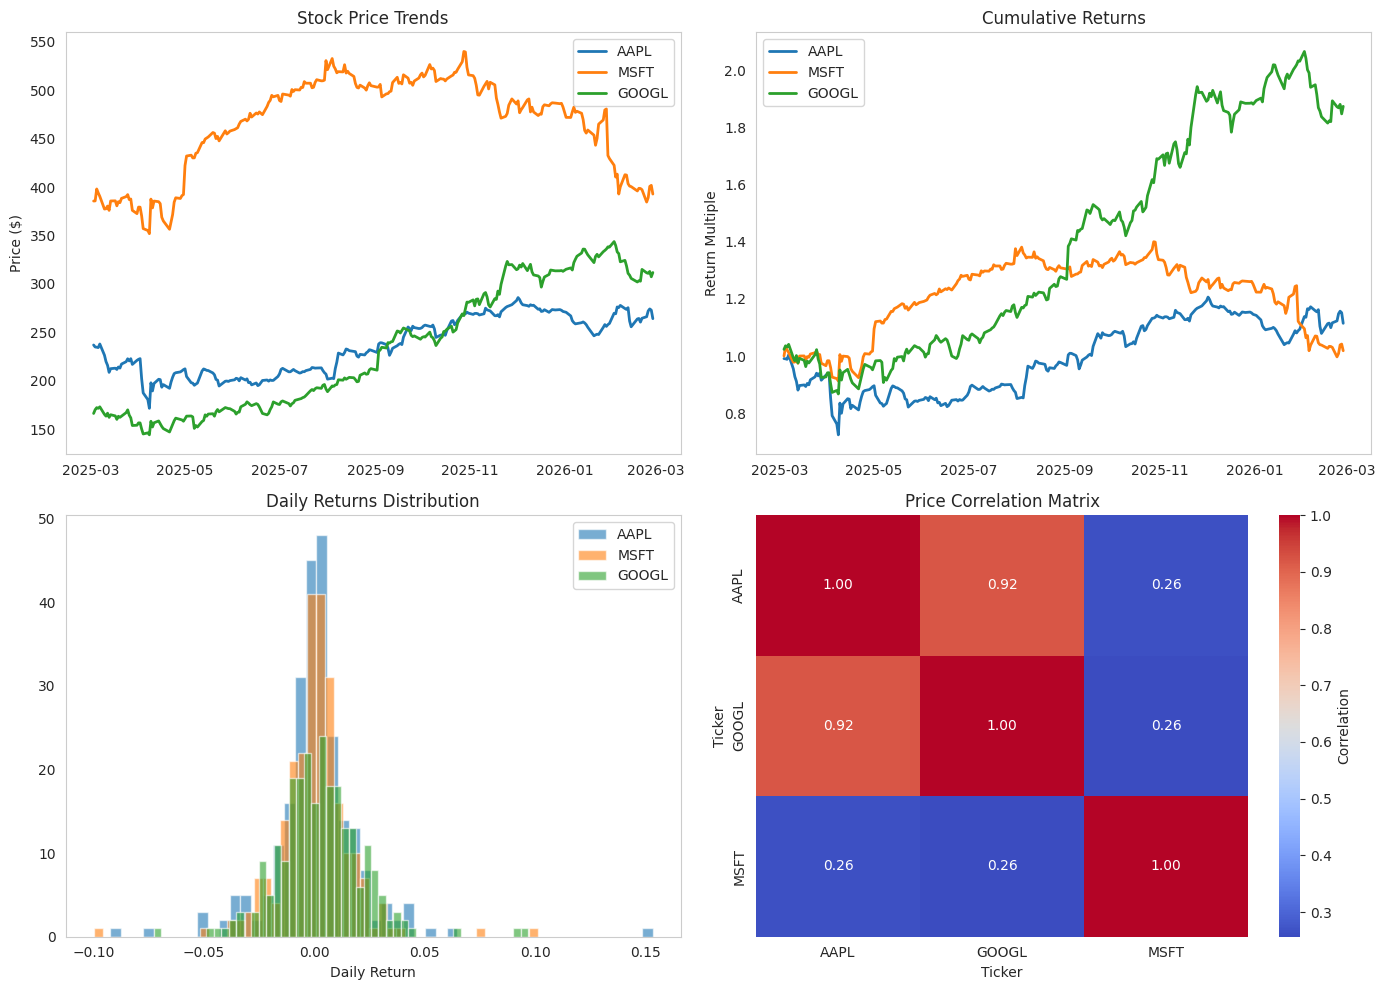

In [10]:
# Plot price trends with moving averages
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price trends
for ticker in tickers:
    axes[0, 0].plot(close_prices.index, close_prices[ticker], label=ticker, linewidth=2)
axes[0, 0].set_title('Stock Price Trends')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].legend()
axes[0, 0].grid()

# Cumulative returns
for ticker in tickers:
    axes[0, 1].plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker, linewidth=2)
axes[0, 1].set_title('Cumulative Returns')
axes[0, 1].set_ylabel('Return Multiple')
axes[0, 1].legend()
axes[0, 1].grid()

# Returns distribution
for ticker in tickers:
    axes[1, 0].hist(daily_returns[ticker].dropna(), bins=50, alpha=0.6, label=ticker)
axes[1, 0].set_title('Daily Returns Distribution')
axes[1, 0].set_xlabel('Daily Return')
axes[1, 0].legend()
axes[1, 0].grid()

# Correlation heatmap
sns.heatmap(close_prices.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Price Correlation Matrix')

plt.tight_layout()
plt.show()

## 6. Statistical Analysis
Perform statistical tests and analysis such as correlation analysis, risk assessment, and trend identification.

In [11]:
# Summary statistics for returns
returns_summary = pd.DataFrame({
    'Mean Daily Return': daily_returns.mean(),
    'Std Dev (Daily)': daily_returns.std(),
    'Annual Return': daily_returns.mean() * 252,
    'Annual Volatility': daily_returns.std() * np.sqrt(252),
    'Sharpe Ratio': sharpe_ratio,
    'Min Return': daily_returns.min(),
    'Max Return': daily_returns.max(),
    'Skewness': daily_returns.skew(),
    'Kurtosis': daily_returns.kurtosis()
})

print("Returns Analysis Summary:")
print(returns_summary.round(4))

# Correlation analysis
print("\n\nPrice Correlation Matrix:")
print(close_prices.corr().round(4))

# Risk metrics
print("\n\nRisk Metrics:")
print(f"Value at Risk (VaR) at 95% confidence:")
for ticker in tickers:
    var_95 = daily_returns[ticker].quantile(0.05)
    print(f"  {ticker}: {var_95:.4f}")

Returns Analysis Summary:
        Mean Daily Return  Std Dev (Daily)  Annual Return  Annual Volatility  \
Ticker                                                                         
AAPL               0.0006           0.0205         0.1619             0.3251   
GOOGL              0.0027           0.0195         0.6838             0.3097   
MSFT               0.0002           0.0168         0.0541             0.2667   

        Sharpe Ratio  Min Return  Max Return  Skewness  Kurtosis  
Ticker                                                            
AAPL          0.4364     -0.0925      0.1533    1.1298   14.2358  
GOOGL         2.1433     -0.0726      0.0968    0.5801    3.9456  
MSFT          0.1279     -0.0999      0.1013    0.2312   10.9704  


Price Correlation Matrix:
Ticker    AAPL   GOOGL    MSFT
Ticker                        
AAPL    1.0000  0.9202  0.2641
GOOGL   0.9202  1.0000  0.2567
MSFT    0.2641  0.2567  1.0000


Risk Metrics:
Value at Risk (VaR) at 95% confidence:
